In [17]:
# Project 1 - Linear Regression on Physiological Signal Data
# Predicting respiration rate from heart rate and Sp02
# Dataset: BIDMC PPG and Respiration Dataset 
import numpy as np
import pandas as pd
import statsmodels.api as sm
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import glob
import os
from ISLP.models import summarize

In [3]:
# Load numerics data for all patients
data_path = r'C:\Users\johna\physiological-signal-ai\raw_data\bidmc-ppg-and-respiration-dataset-1.0.0\bidmc_csv'
#Stores the folder path as a string. The r before the quote means raw string — it tells Python to treat backslashes as literal characters,
#not escape sequences. Without r, \b would be interpreted as a special character.

all_numerics = [] #Creates an empty list to collect dataframes from each patient. Think of it as an empty box we'll fill one patient at a time.

for i in range(1, 54): #Loops from 1 to 53 — one iteration per patient.
    filename = f'bidmc_{i:02d}_Numerics.csv' #Creates the filename for each patient. f'...' is an f-string.
    #{i:02d} formats the number with 2 digits — so patient 1 becomes 01, patient 9 becomes 09, patient 10 stays 10.
    filepath = os.path.join(data_path, filename) #Combines the folder path and filename into a full file path.
    #os.path.join handles this cleanly across different operating systems.
    df = pd.read_csv(filepath) #Loads that patient's CSV file into a dataframe.
    df['patient_id'] = i #Adds a new column with the patient number so we know which patient each row belongs to after combining.
    all_numerics.append(df) #Adds that patient's dataframe to our list.

numerics = pd.concat(all_numerics, ignore_index=True) #Combines all 53 dataframes into one. ignore_index=True resets the row numbers from
#0 to 25492 instead of repeating 0-479 for each patient.
numerics.columns = numerics.columns.str.strip() #Removes leading and trailing spaces from column names. 
print(numerics.shape) #Prints the dimensions 
numerics.head() #shows the first 5 rows to confirm everything loaded correctly.

(25493, 6)


,Time [s],HR,PULSE,RESP,SpO2,patient_id
0,0,94.0,93.0,25.0,97.0,1
1,1,94.0,93.0,25.0,97.0,1
2,2,94.0,93.0,25.0,97.0,1
3,3,92.0,93.0,26.0,97.0,1
4,4,93.0,93.0,26.0,97.0,1


In [7]:
print(numerics.isnull().sum()) # isnull() - checks every cell — True if missing, False if not. 
#.sum() - counts the Trues per column. Prints how many missing values each column has.
print("\n")
print(numerics[['HR', 'SpO2', 'RESP']]. describe()) #Selects only the three columns we care about — HR, SpO2 and RESP
#.describe() - gives count, mean, std, min, max and quartiles for each. Quick statistical overview of our three main variables.

Time [s]        0
HR              4
PULSE         128
RESP          153
SpO2          128
patient_id      0
dtype: int64


                 HR          SpO2          RESP
count  25489.000000  25365.000000  25340.000000
mean      89.180588     96.722649     17.497119
std       13.326752      3.301982      3.444627
min       44.000000     83.000000      0.000000
25%       81.000000     95.000000     16.000000
50%       89.000000     98.000000     18.000000
75%       95.000000     99.000000     19.000000
max      139.000000    100.000000     34.000000


In [ ]:
#HR — mean 89 bpm, range 44-139. Normal resting heart rate is 60-100, so this ICU population is slightly elevated
#SpO2 — mean 96.7%, range 83-100. Normal is above 95%, so most patients are fine but some are critically low at 83%
#RESP — mean 17.5 breaths/minute, range 0-34. Normal is 12-20, so some patients are breathing very fast (tachypnea)

In [8]:
numerics_clean = numerics[['HR', 'SpO2', 'RESP', 'patient_id']].dropna()#Selects only the four columns we need, drops Time and PULSE which we won't use.
#.dropna() - Removes any row that has at least one missing value.
numerics_clean = numerics_clean[numerics_clean['RESP']>0]#Filters out rows where RESP is zero,
#those are likely sensor errors n't real zero breathing rates
print(numerics_clean.shape)

(24988, 4)


In [ ]:
#24,988 clean rows after removing missing values and zero respiration rates. Lost about 500 rows total which is acceptable.

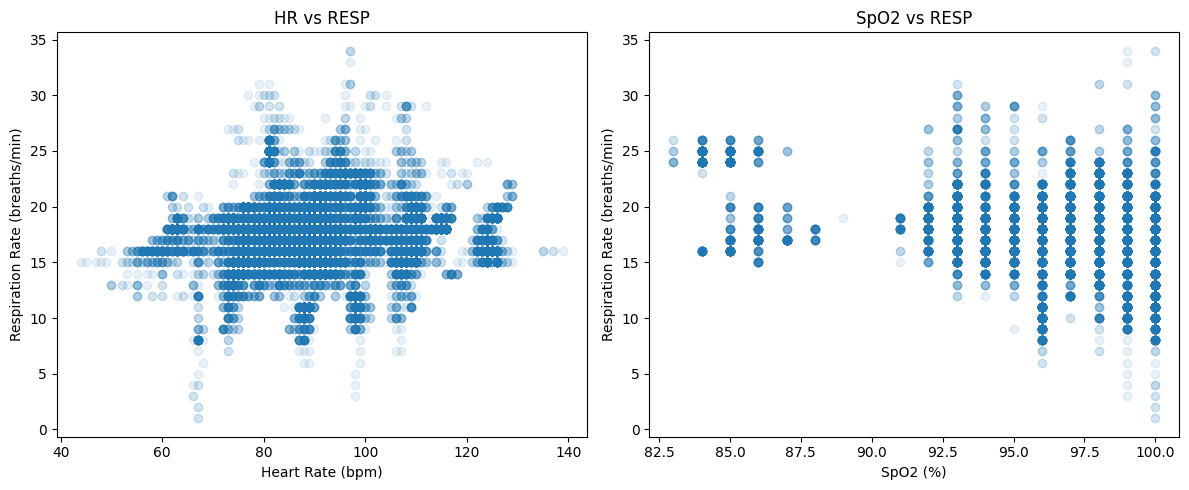

In [24]:
#exploring the relationships visually before modeling
fig, axes = subplots(1, 2, figsize=(12, 5)) #Creates one figure with two side by side plots. 1, 2 means 1 row, 2 columns of plots.

axes[0].scatter(numerics_clean['HR'], numerics_clean['RESP'], alpha=0.1)
#Scatterplot on the left. alpha=0.1 makes points 90% transparent — essential when you have 25,000 points overlapping.
#Without it everything merges into a solid blob.
axes[0].set_xlabel('Heart Rate (bpm)')
axes[0].set_ylabel('Respiration Rate (breaths/min)')
axes[0].set_title('HR vs RESP')

axes[1].scatter(numerics_clean['SpO2'], numerics_clean['RESP'], alpha=0.1)
axes[1].set_xlabel('SpO2 (%)')
axes[1].set_ylabel('Respiration Rate (breaths/min)')
axes[1].set_title('SpO2 vs RESP')

fig.tight_layout() #Automatically adjusts spacing between plots so they don't overlap.
fig.savefig("Visual relationship",dpi=152)

In [ ]:
#HR vs RESP (left plot): There's a weak positive relationship — as heart rate increases, respiration rate tends to increase slightly. 
#But the cloud is very wide and scattered. The relationship exists but is not strong. This makes clinical sense — both increase when a patient 
#is under stress or has breathing difficulty, but they're not tightly coupled.

#SpO2 vs RESP (right plot): The vertical stripe pattern is interesting — SpO2 values are discrete (whole numbers like 95, 96, 97) which is why you
#see columns instead of a smooth cloud. The relationship with RESP looks weak and unclear. Low SpO2 patients show a wide range of respiration rates.
#What this tells us before modeling:Neither predictor has a strong linear relationship with RESP. Our regression model will work 
#but probably won't be highly accurate. That's an honest and important finding — and worth stating in a paper.

In [14]:
print(numerics_clean[['HR', 'SpO2', 'RESP']].corr())
# .corr() Calculates the correlation coefficient between every pair of columns. Values range from -1 to +1. Close to 0 means weak relationship.

            HR      SpO2      RESP
HR    1.000000  0.031070  0.053416
SpO2  0.031070  1.000000 -0.292526
RESP  0.053416 -0.292526  1.000000


In [ ]:
#HR vs RESP = 0.053
#Almost zero — heart rate has virtually no linear relationship with respiration rate. Very weak.
#SpO2 vs RESP = -0.292: Moderate negative relationship — as SpO2 increases, respiration rate tends to decrease.
#This makes clinical sense — when oxygen levels drop, patients breathe faster to compensate. SpO2 is the more useful predictor.
#HR vs SpO2 = 0.031:Nearly zero — heart rate and SpO2 are essentially uncorrelated. Good — means our two predictors aren't redundant.

In [18]:
#Building the regression method
X = sm.add_constant(numerics_clean[['HR', 'SpO2']]) # adds the intercept column of ones 
y = numerics_clean['RESP'] # the response variable - what we are predicting
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =0)# splits data 80% for training and 20% for testing
model = sm.OLS(y_train, X_train). fit() # fits linear regression on training data only
summarize (model) # show coefficients, standars errors and p-values

,coef,std err,t,P>|t|
const,42.2603,0.608,69.451,0.0
HR,0.0149,0.002,9.650,0.0
SpO2,-0.2681,0.006,-43.445,0.0


In [ ]:
#both predictors are highly significant(p=0.0)
RESP = 42.26 + 0.015 × HR - 0.268 × SpO2
#const = 42.26 - When HR and SpO2 are both zero — not meaningful clinically, just the mathematical intercept.
#HR = 0.015 - For every 1 bpm increase in heart rate, respiration rate increases by 0.015 breaths/min — holding SpO2 constant. Very small effect.
#SpO2 = -0.268 - For every 1% increase in SpO2, respiration rate decreases by 0.268 breaths/min — holding HR constant. 
#This is the clinically meaningful result — higher oxygen levels mean slower breathing.
#SpO2 is clearly the dominant predictor — its coefficient is 18 times larger than HR's, and its t-statistic (-43) is much larger than HR's (9).

In [19]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"R-squared: {model.rsquared:.4f}")

Test MSE: 8.4877
Test RMSE: 2.9134
R-squared: 0.0891


In [ ]:
#RMSE = 2.91 breaths/min: The model's predictions are off by about 3 breaths/min on average. Normal respiration rate is 12-20, 
#so being off by 3 is a meaningful error clinically.
#R-squared = 0.089: The model explains only 8.9% of the variation in respiration rate. That's low — HR and SpO2 together don't capture most of what
#drives breathing rate in ICU patients.
#Is this a bad result? Not necessarily — it's an honest result. It tells us that respiration rate is driven by many factors beyond 
#just HR and SpO2 — patient condition, medication, lung disease, pain level. A simple linear model with two predictors can't capture all of that.
#In a paper you would write: "Linear regression using HR and SpO2 as predictors achieved an RMSE of 2.91 breaths/min and R² of 0.089, 
#suggesting that these two variables alone have limited predictive power for respiration rate."

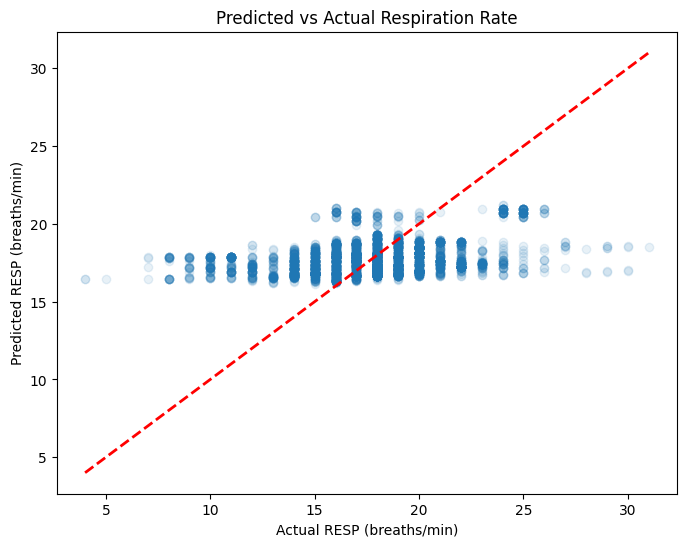

In [26]:
fig, ax = subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.1) #Plots actual values on x-axis against predicted values on y-axis. 
#If the model were perfect, all points would lie on a diagonal line.
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2) # Draws a perfect prediction line in red dashes,the diagonal reference line. Points close to this line are good predictions.
ax.set_xlabel('Actual RESP (breaths/min)')
ax.set_ylabel('Predicted RESP (breaths/min)')
ax.set_title('Predicted vs Actual Respiration Rate')
fig.savefig('predicted vs Actual RR',dpi =152)

In [ ]:
#The predicted values are clustered in a narrow horizontal band between about 15-21 breaths/min regardless of what the actual value is. 
#The model is essentially predicting "around 17-18" for almost every patient.
#For actual values between 15-20 the predictions are reasonable — that's where the points cluster near the red line. 
#But for patients with very low RESP (below 10) or very high RESP (above 25), the model completely fails — 
#it still predicts around 17-18 while the actual is far away.
#Why this happens:The model learned the average respiration rate and shifts it slightly based on HR and SpO2. But since R² is only 9%, 
#it has almost no real predictive power at the extremes.
#The clinical implication:
#This model would miss the most critical patients — the ones breathing too slowly or too fast are exactly who doctors most need to identify.